# Phase 1: Data Ingestion & Exploratory Data Analysis (EDA)
This notebook handles the initial raw excel ingestion, performs text column sanitization, checks structural details, and splits data into raw validation chunks.

In [1]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split

### 1. Ingest Excel Workbook

In [2]:
raw_data_path = "../data/dataexport.xlsx"
df = pd.read_excel(raw_data_path, sheet_name='20m data')
df.columns = df.columns.str.strip()
df.head()

,Län,Vägnummer,Riktning,KF,StartLL,SlutLL,Nättyp,IRI höger,Spårdjup max 15,ÅDT fordon,Beläggningsår,Hastighetsgräns
0,"Östergötland(E, 5)",4.0,Med,K1,59992,60012,Väg,0.59,1.95,12223,2024,120
1,"Östergötland(E, 5)",4.0,Med,K1,60012,60032,Väg,0.67,1.95,12223,2024,120
2,"Östergötland(E, 5)",4.0,Med,K1,60032,60052,Väg,0.64,1.95,12223,2024,120
3,"Östergötland(E, 5)",4.0,Med,K1,60052,60072,Väg,0.59,1.95,12223,2024,120
4,"Östergötland(E, 5)",4.0,Med,K1,60072,60092,Väg,0.59,1.95,12223,2024,120


### 2. Basic Dataset Profiling

In [3]:
print("--- Dataset Info ---")
print(df.info())
print("\n--- Target Profile (IRI höger) ---")
print(df['IRI höger'].describe())

--- Dataset Info ---
<class 'pandas.DataFrame'>
RangeIndex: 41240 entries, 0 to 41239
Data columns (total 12 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Län              41240 non-null  str    
 1   Vägnummer        41240 non-null  float64
 2   Riktning         41240 non-null  str    
 3   KF               41240 non-null  str    
 4   StartLL          41240 non-null  int64  
 5   SlutLL           41240 non-null  int64  
 6   Nättyp           41240 non-null  str    
 7   IRI höger        41240 non-null  float64
 8   Spårdjup max 15  41240 non-null  float64
 9   ÅDT fordon       41240 non-null  int64  
 10  Beläggningsår    41240 non-null  int64  
 11  Hastighetsgräns  41240 non-null  int64  
dtypes: float64(3), int64(5), str(4)
memory usage: 4.9 MB
None

--- Target Profile (IRI höger) ---
count    41240.000000
mean         2.111253
std          1.545723
min          0.320000
25%          0.950000
50%          1.680000
75%   

### 3. Visualizing Key Distribution

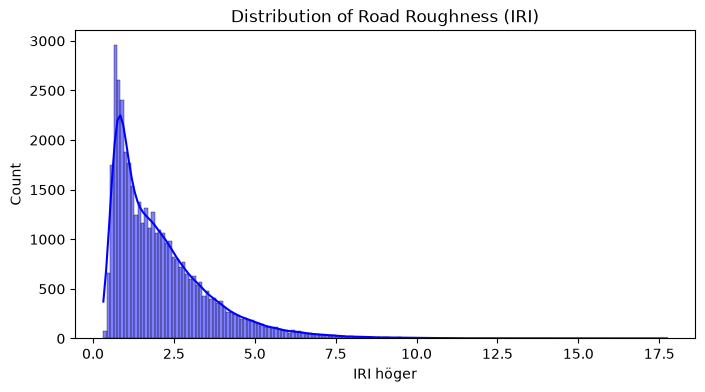

In [4]:
plt.figure(figsize=(8, 4))
sns.histplot(df['IRI höger'], kde=True, color='blue')
plt.title('Distribution of Road Roughness (IRI)')
plt.xlabel('IRI höger')
plt.show()

### 4. Create and Save Train/Test Splits

In [5]:
os.makedirs("../artifacts", exist_ok=True)
train_set, test_set = train_test_split(df, test_size=0.2, random_state=42)

train_set.to_csv("../artifacts/train.csv", index=False)
test_set.to_csv("../artifacts/test.csv", index=False)
print(f"Exported splits. Train size: {len(train_set)}, Test size: {len(test_set)}")

Exported splits. Train size: 32992, Test size: 8248
